<a href="https://colab.research.google.com/github/Rishsing73/rishsing73.github.io/blob/master/NumerAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ATTENTION!!! YOU MUST RUN EACH CODE BLOCK FROM TOP TO BOTTOM IN ORDER TO EXECUTE THE CODE!!!
We don't need to worry about validation set, it is provided so use training.

In [16]:
#import statements always go first
!pip install pandas sklearn numerapi
import pandas as pd
import numpy as np
import sklearn #this is the Scikit-Learn package (sklearn for short)

Scikit-Learn has conventions for code which must be followed. For instance, an algorithm requires training data. We already know that the Numerai data is labeled as features and targets, and observations exist in eras.
So, our rows are the observations, features are the independent variables, and the target is the dependent variable.
We will have a matrix of n observations, X columns, and the y target. Your data should conform to this convention in every step of your process!

In [3]:
#define variables used inside functions above those functions

tour_datalink = 'https://numerai-public-datasets.s3-us-west-2.amazonaws.com/latest_numerai_tournament_data.csv.xz'
train_datalink = 'https://numerai-public-datasets.s3-us-west-2.amazonaws.com/latest_numerai_training_data.csv.xz'
df_train = pd.read_csv(train_datalink, ) #download the training data and keep only the first 50,000 rows
df_tour = pd.read_csv(tour_datalink, )
#df_train = pd.read_csv('https://numerai-public-datasets.s3-us-west-2.amazonaws.com/latest_numerai_training_data.csv.xz', nrows=50000) #this line of code would also work


Let's break the training data into the parts we need. First, let's create our dependent variable as a new object, y.

In [5]:

# y_train = df_train.target.values  #we use the .values command to extract only the numerical values from the column 'target_kazutsugi'
 # to get info about data
# df_tour[df_tour.data_type == 'validation'].head(-5)

Let's also create a shortcut to access the feature columns

In [6]:
# df_train[df_train.data_type == 'live'].head(-5)

In [7]:
#create your training matrix of the 310 features
#there are several ways to do this! This is a way to maintain the dataframe's structure but to isolate the feature columns.
features = [c for c in df_train if c.startswith("feature")] # good enough
# df_train['id'].value_counts() #it would have been usefull if we had a test column which had categories



Have we accomplished our goal? Let's check!

In [12]:
df_tour['data_type'].describe() #first 10 rows

count     1655135
unique          3
top          test
freq      1511996
Name: data_type, dtype: object

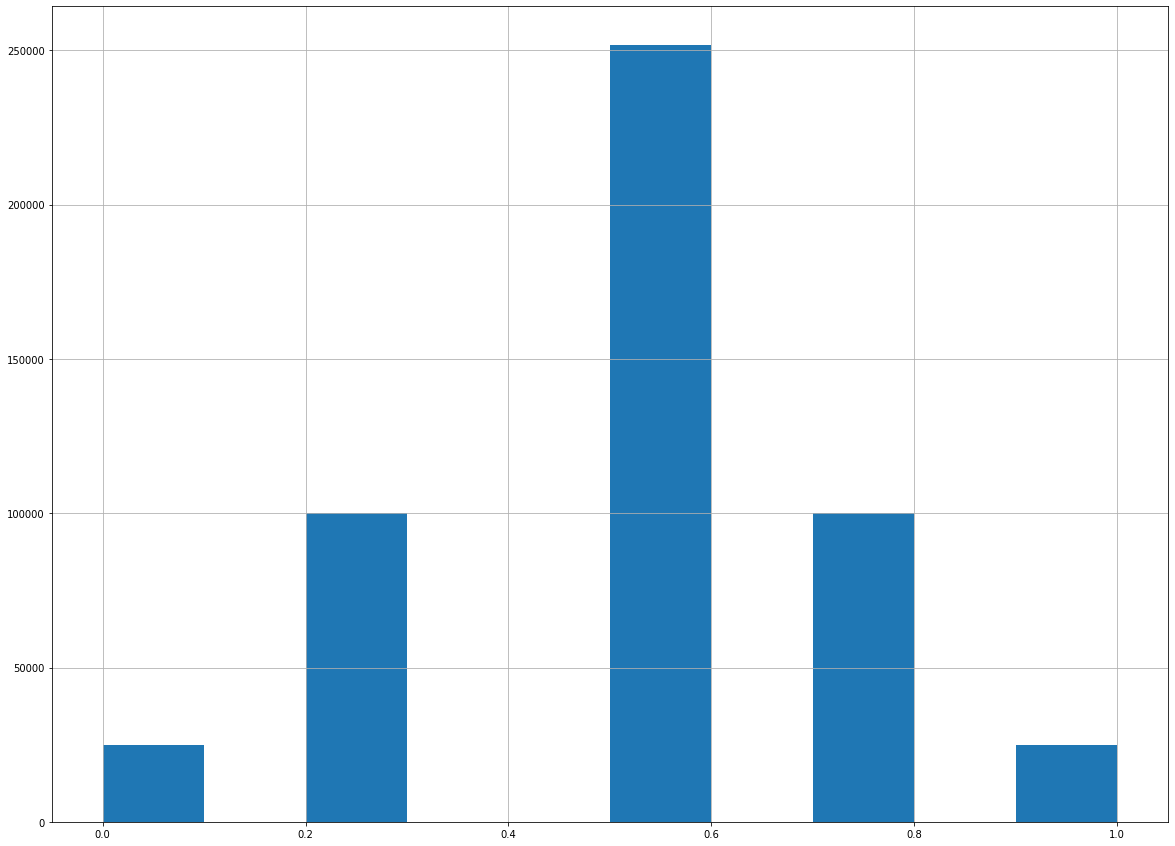

In [13]:
# df_train.feature_intelligence3.describe() # using it gain insight in the data dstribution
import matplotlib.pyplot as plt
df_train['target'].hist(bins = 10, figsize=(20,15))



Let's look at just one Era

In [4]:
# era2 = df_train[df_train.era == "era2"].copy()
# era2.describe()

You do it! Follow the two code blocks above, and print the descriptive statistics for the second era.

In [14]:
# era1 = df_train[df_train.era == "era1"].copy()
# era1.describe()

# the data is distributed in the same manner in each era, with same mean, std etc.
## NO insight with the plotting, moving to multiple linear regression
## Also splitting random, later we will split themby categoriesing Y


In [8]:
from sklearn.model_selection import train_test_split
# train_set, test_set = train_test_split(df_train, test_size=0.1, random_state=42)
#hint: You have to change some things in order to select the second era, but the code above works and can be modified for your use.
X_train =df_train[features].values
Y_train = df_train['target'].values
test = df_tour[df_tour.data_type == 'validation'].copy()
X_test = test[features].values
Y_test = test['target'].values

Now that you've explored the data a little bit, let's begin to use Scikit-Learn with our subsample.
Begin with Generalized Linear Models: https://scikit-learn.org/stable/modules/linear_model.html
Scikit-learn is extremely well documented. Most algorithms come with code examples. Let's first take a look at Ordinary Least Squares.
The documentation shows that LinearRegression is part of the linear_model module. To use any algorithm in linear_model, we must first import the module.

### No insight upon plotting :<
### very encrypted data

In [17]:
# df_train.plot(kind = "scatter", x = 'feature_intelligence1', y = 'target', alpha = 0.4)

In [9]:
corr_matrix = df_train.corr()

### We can see that target is correlated to some of them bt very little
### we will also check if how one feature is correlated to another. It looks like one feature is crr to few but mostly they are uncorrelated (especially Target)

In [18]:
# a = corr_matrix['target'].sort_values(ascending = False)

# a[1:].hist(bins = 40, figsize = (20,15))


In [10]:
from sklearn.linear_model import LinearRegression #This is how you import a specific module to your python environment. In order to use LinearRegression, we must access LinearRegression within the linear_model module.

LinearRegression takes several parameters.

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression

Visiting the above link shows you the source code for LinearRegression.

You can see that:
    
    sklearn.linear_model.LinearRegression(fit_intercept=True, normalize=False, copy_X=True, n_jobs=None)

represents the default settings for the algorithm. This is a standard presentation format throughout Scikit-Learn.

We can ignore the default parameters and focus on using the algorithm, since LinearRegression is such a basic algorithm.

Below the explanation of the parameters, you'll see an "Examples" section.

We need to define our explanatory variables (independent variables, "features") and our dependent variable, y. We can define X as:

`X = df_train[features].values`

You need to copy the line of code above and paste it in the cell below in order to define X. Run the cell.

In [11]:
lin_reg = LinearRegression()


Also, we can define the algorithm as its own python variable. The example names LinearRegression as reg.

You can do this as well, or call the algorithm whatever you want. Personally, I like to use a systematic naming method, because I often evaluate several versions of the algorithm at once.

`REG1 = linear_model.LinearRegression()`

You need to copy the line of code above and paste it in the cell below in order to define REG1. Run the cell.

In [12]:
REG1 = lin_reg.fit(X_train,Y_train)
from scipy import stats
Y_predict = REG1.predict(X_test)
# lin_mse = mean_squared_error(Y_test,Y_predict)



In [23]:
stats.spearmanr(Y_predict,Y_test)

SpearmanrResult(correlation=0.015771798409123027, pvalue=4.782147646827083e-09)

In [14]:
live_features = df_tour[features]
predictions = REG1.predict(live_features)
predictions_df = df_tour["id"].to_frame()
predictions_df["prediction_kazutsugi"] = predictions
predictions_df.head()

,id,prediction_kazutsugi
0,n0003aa52cab36c2,0.481608
1,n000920ed083903f,0.492837
2,n0038e640522c4a6,0.530817
3,n004ac94a87dc54b,0.497083
4,n0052fe97ea0c05f,0.503089


In [19]:
import numerapi
public_id = "MVBZJGWINL43C36X5DTOO5WJ2GZ6UTDV"
secret_key = "CMD6W6V2ATKYTCTYGDJNJM32ESAVRNUV6N3SKCIJUU75NU2XYDME26UNBUHOKGG6"
model_id = "ec19da33-cfe2-4a7c-bd3c-8dd6822d2f12"
napi = numerapi.NumerAPI(public_id=public_id, secret_key=secret_key)

In [21]:
predictions_df.to_csv("predictions1.csv", index=False)
submission_id = napi.upload_predictions("predictions1.csv", model_id=model_id)

2021-02-21 13:13:42,168 INFO numerapi.base_api: uploading predictions...


In [ ]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor()
Reg2 = tree_reg.fit(X_train,Y_train)
Y_predict2 = tree_reg.predict(X_test)
lin_mse2 = mean_squared_error(Y_test,Y_predict2)
lin_mse2

0.1067125

Now, REG1 is my algorithm, and I can access commands using "." (Dot Notation)

We have to fit the algorithm to the training data.

In [ ]:
from sklearn.model_selection import cross_val_score
lin_scores = cross_val_score(lin_reg, X_train, Y_train,
                             scoring="neg_mean_squared_error", cv=10)


ValueError: ignored

In [ ]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor()
forest_reg.fit(X_train, Y_train)


NameError: ignored

In [ ]:
#YOU DO IT! Fit your algorithm to the training data.
Y_predict3 = forest_reg.predict(X_test)
fr_err = mean_squared_error(Y_predict3,Y_test)
Y_predict3,Y_test

(array([0.5875, 0.455 , 0.52  , ..., 0.525 , 0.5075, 0.4925]),
 array([0.75, 0.5 , 0.5 , ..., 0.75, 0.5 , 0.  ]))

Let's see how the model performed by using the .score() function.
After you've fit an algorithm in scikit-learn, you can evaluate the in-sample performance by using .score()

`REG1.score(X, y)`

Running the code snippet above will give you the R-squared value for the model. A score close to 1 is very good. A score close to zero is very bad. But remember! This is only an in-sample estimate!

You do it! Run your model's .score() and evaluate the R-squared value.

In [ ]:
#Copy the code from the cell above to produce the model's score
lin_reg.score(X_test,Y_test)

-0.0025349625045842927

You've now fit a model to a subset of the training data. If you can do this using LinearRegression, then what other algorithms can you use within the linear_model module?

https://scikit-learn.org/stable/modules/classes.html#module-sklearn.linear_model

ASSIGNMENT:

```
PICK ANY ALGORITHM FROM THE LINK ABOVE OTHER THAN LINEARREGRESSION AND FIT THE ALGORITHM TO THE TRAINING DATA.

SCORE YOUR MODEL USING THE .SCORE() FUNCTION.
```

Congratulations! You have successfully demonstrated how to: define your training data, fit a machine learning model to the data, and evaluate the model's in-sample performance.

Don't stop now! Read other sections of scikit-learn and see which models you can use for a regression task.

ASSIGNMENT:

```
NAME 5 ALGORITHMS WHICH WILL WORK WITH A REGRESSION TASK.
IMPORT THEM TO THIS SHEET. AT LEAST ONE MUST COME FROM A MODULE OTHER THAN LINEAR_MODEL.

REMEMBER, SCIKIT-LEARN IS VERY WELL DOCUMENTED! GOOGLE IS YOUR FRIEND! DO SOME WORK!
```